## DeBERTa-v3 Fine-Tuning for Disaster Tweet Classification

### Objective

Fine-tune Microsoft's DeBERTa-v3 (Decoding-enhanced BERT with Disentangled Attention) model on the Kaggle Disaster Tweets dataset.

Tasks:

- Load the cleaned dataset
- Split into training and validation sets
- Tokenize tweets using the DeBERTa tokenizer
- Fine-tune DeBERTa-v3
- Evaluate performance
- Compare results with:
  - Logistic Regression
  - BERT


In [1]:
# Install stable Hugging Face dependencies for Google Colab
%pip install -q transformers==4.46.3 huggingface_hub==0.26.2 accelerate==1.1.1 sentencepiece

# transformers==4.46.3:
# Provides the stable Hugging Face API used for DeBERTa-v3 fine-tuning:
# AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,
# Trainer, and TrainingArguments. Pinning avoids experimental Transformers 5.x behavior and ensures compatibility with this notebook.

# huggingface_hub==0.26.2:
# Handles reliable model and tokenizer downloads from the Hugging Face Hub.
# This compatible version removes the need for manual wget downloads, HF tokens,local config files, or manual model-weight loading.

# accelerate==1.1.1:
# Required by Hugging Face Trainer to manage device placement and training on Google Colab's T4 GPU efficiently.

# sentencepiece:
# Required by the DeBERTa-v3 tokenizer to load and process its SentencePiece vocabulary files correctly in Google Colab.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 49.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.26.2 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.2 which is incompatible.


In [21]:
# Import libraries

import numpy as np
import pandas as pd
from google.colab import files
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


In [3]:
# Define pretrained model

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 128


In [4]:
# Upload dataset

files.upload()


Saving cleaned_train.csv to cleaned_train.csv


{'cleaned_train.csv': b'id,keyword,location,text,target,text_length,cleaned_text\r\n1,,,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,69,deeds reason earthquake may allah forgive us\r\n4,,,Forest fire near La Ronge Sask. Canada,1,38,forest fire near la ronge sask canada\r\n5,,,All residents asked to \'shelter in place\' are being notified by officers. No other evacuation or shelter in place orders are expected,1,133,residents asked shelter place notified officers evacuation shelter place orders expected\r\n6,,,"13,000 people receive #wildfires evacuation orders in California ",1,65,13000 people receive wildfires evacuation orders california\r\n7,,,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school ,1,88,got sent photo ruby alaska smoke wildfires pours school\r\n8,,,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,1,110,rockyfire update california hwy 20 closed di

In [5]:
train_df = pd.read_csv("cleaned_train.csv")

print(f"Dataset Shape : {train_df.shape}")
train_df.head()


Dataset Shape : (7613, 7)


,id,keyword,location,text,target,text_length,cleaned_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,deeds reason earthquake may allah forgive us
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,residents asked shelter place notified officer...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,13000 people receive wildfires evacuation orde...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,got sent photo ruby alaska smoke wildfires pou...


In [6]:
# Check missing values

train_df[["cleaned_text", "target"]].isnull().sum()


,0
cleaned_text,0
target,0


In [7]:
# Split features and labels into training and validation sets

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["cleaned_text"],
    train_df["target"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["target"],
)

print(f"Training Samples   : {len(train_texts)}")
print(f"Validation Samples : {len(val_texts)}")


Training Samples   : 6090
Validation Samples : 1523


In [9]:
# Load the pretrained tokenizer through the Hugging Face Hub

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer


DebertaV2TokenizerFast(name_or_path='microsoft/deberta-v3-base', vocab_size=128000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [10]:
# Tokenize tweets without fixed padding

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
)
val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
)

train_encodings.keys()


dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

In [11]:
# Define custom dataset class

class DisasterDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.to_numpy()

    def __getitem__(self, index):
        item = {key: values[index] for key, values in self.encodings.items()}
        item["labels"] = int(self.labels[index])
        return item

    def __len__(self):
        return len(self.labels)


In [12]:
# Create training and validation datasets

train_dataset = DisasterDataset(train_encodings, train_labels)
val_dataset = DisasterDataset(val_encodings, val_labels)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Training Dataset: {len(train_dataset)}")
print(f"Validation Dataset: {len(val_dataset)}")


Training Dataset: 6090
Validation Dataset: 1523


In [13]:
# Load the pretrained DeBERTa-v3 classification model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
# Compute evaluation metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [17]:
# Define training arguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
)


In [18]:
# Create Trainer, fine-tune the model, and save the best checkpoint

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.evaluate()
trainer.save_model("./final_deberta_disaster_model")
tokenizer.save_pretrained("./final_deberta_disaster_model")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.458200,0.408226,0.843073,0.899807,0.714067,0.796249
2,0.377400,0.379007,0.849639,0.836767,0.807339,0.821790
3,0.291000,0.399796,0.848982,0.848684,0.788991,0.817750


('./final_deberta_disaster_model/tokenizer_config.json',
 './final_deberta_disaster_model/special_tokens_map.json',
 './final_deberta_disaster_model/spm.model',
 './final_deberta_disaster_model/added_tokens.json',
 './final_deberta_disaster_model/tokenizer.json')

In [22]:
# Generate validation predictions from the best checkpoint

prediction_output = trainer.predict(val_dataset)

validation_logits = prediction_output.predictions
validation_labels = prediction_output.label_ids
validation_predictions = np.argmax(validation_logits, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    validation_labels,
    validation_predictions,
    average="binary",
    zero_division=0,
)

validation_accuracy = accuracy_score(
    validation_labels,
    validation_predictions,
)

print(f"Validation Accuracy : {validation_accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

Validation Accuracy : 0.8496
Precision           : 0.8368
Recall              : 0.8073
F1 Score            : 0.8218


In [23]:
# Display class-level validation metrics

print(
    classification_report(
        validation_labels,
        validation_predictions,
        target_names=["Non-Disaster", "Disaster"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

Non-Disaster       0.86      0.88      0.87       869
    Disaster       0.84      0.81      0.82       654

    accuracy                           0.85      1523
   macro avg       0.85      0.84      0.85      1523
weighted avg       0.85      0.85      0.85      1523



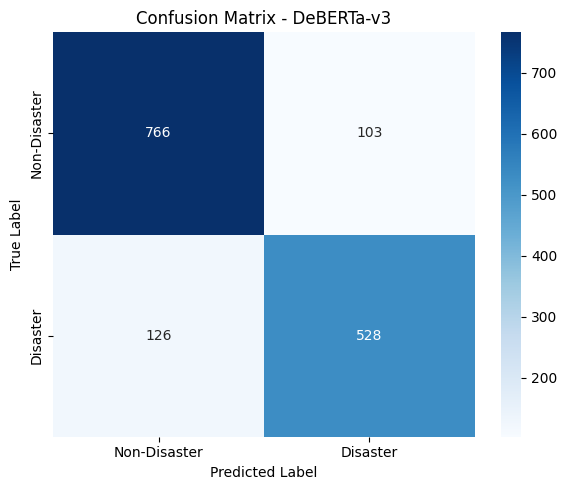

In [24]:
# Visualize validation predictions with a confusion matrix

confusion_matrix_values = confusion_matrix(
    validation_labels,
    validation_predictions,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Disaster", "Disaster"],
    yticklabels=["Non-Disaster", "Disaster"],
)

plt.title("Confusion Matrix - DeBERTa-v3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [20]:
# Compare validation performance across experiments

model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "BERT",
            "DeBERTa-v3",
        ],
        "Accuracy": [
            0.8221,
            0.8444,
            0.8496,
        ],
        "Precision (Disaster)": [
            0.8488,
            0.8200,
            0.8368,
        ],
        "Recall (Disaster)": [
            0.7125,
            0.8100,
            0.8073,
        ],
        "F1 Score (Disaster)": [
            0.7747,
            0.8200,
            0.8218,
        ],
    }
).sort_values("F1 Score (Disaster)", ascending=False)

model_comparison.reset_index(drop=True)

,Model,Accuracy,Precision (Disaster),Recall (Disaster),F1 Score (Disaster)
0,DeBERTa-v3,0.8496,0.8368,0.8073,0.8218
1,BERT,0.8444,0.8200,0.8100,0.8200
2,Logistic Regression,0.8221,0.8488,0.7125,0.7747


In [25]:
# Save the best model checkpoint and tokenizer

MODEL_OUTPUT_DIR = "./final_deberta_disaster_model"

trainer.save_model(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

print(f"Model and tokenizer saved to: {MODEL_OUTPUT_DIR}")

Model and tokenizer saved to: ./final_deberta_disaster_model
